# Análisis Exploratorio de Datos (EDA)
## Base de Trabajo de Grado — Empleados Colombia (Permanentes)

Este notebook realiza un análisis exploratorio exhaustivo sobre la base de datos de empleados. El objetivo es comprender la estructura, distribución, calidad y relaciones entre las variables del dataset, con foco en la rotación de personal.

**Secciones:**
1. Carga de datos y librerías
2. Inspección general del dataset
3. Análisis de calidad de datos (nulos, duplicados, tipos)
4. Ingeniería de variables derivadas
5. Análisis univariado — Variables categóricas
6. Análisis univariado — Variables numéricas
7. Análisis bivariado
8. Análisis de correlaciones
9. Análisis temporal (antigüedad y tendencias)
10. Análisis de rotación (turnover)
11. Resumen de hallazgos clave

---
## 1. Carga de datos y librerías

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100

pd.set_option('display.max_columns', 40)
pd.set_option('display.max_colwidth', 50)
pd.set_option('display.float_format', '{:.4f}'.format)

print('Librerías cargadas correctamente.')


Librerías cargadas correctamente.


In [2]:
import os

while os.path.basename(os.getcwd()) != "tesis_maestria":
    os.chdir("..")
 
os.getcwd()

'c:\\Users\\piraquive.d\\Documents\\TrabajoGradoMaestria2026\\tesis_maestria'

In [3]:
import sys
print(sys.executable)
!{sys.executable} -m pip install --upgrade pip
!{sys.executable} -m pip install openpyxl

c:\Users\piraquive.d\AppData\Local\Programs\Python\Python311\python.exe


In [4]:
df = pd.read_excel("data/Base_Trabajo_Grado_fin.xlsx")
print(f'Dataset cargado: {df.shape[0]} filas × {df.shape[1]} columnas')
df.head(10)

Dataset cargado: 5792 filas × 40 columnas


,Employee Code,Termination Code,Hours/ Week,Currency Code,English Reading Lvl,English Spoken Lvl,English Writing Lvl,Spanish Reading Lvl,Spanish Spoken Lvl,Spanish Writing Lvl,Union,Employee Job ID,Gender,Marital Status,Area,Grouped Department Name,Job Level,Location Description,Type Location,Contract Type,Exchange Rate,Type,Termination Reason,Termination Type,Target Bonus %,Non Exempt,Active Employee,Hire Date,Termination Date,Target Equity %,Standardized_Salary,Active Supervisor,Supervisor Code,Gropued Supervisor Department,Supervisor Job ID,Probation Period Completed,Position vs Estimated Median,AGE,CPI,Cantidad Salarios Minimos
0,EMP_00001,J,48,COP,3,3,3,4,4,4,N,Cargo 1,Male,Common Law,CLUB OPERATIONS,Merchandising & Inventory,7,Pacífico I,Club,Full Time,3001.5000,C,Violation of Policy (Involun),Involuntary,0.0000,Non Exempt,N,2011-06-20,2013-09-27 00:00:00,0.0000,0.1996,N,Inactive,Inactive,Cargo 342,Yes,0.9124,33.0000,0.0194,66
1,EMP_00002,NaN,44,COP,0,0,0,4,4,4,N,Cargo 2,Male,Married,CLUB OPERATIONS,Fresh & Food Operations,5,Caribe I,Club,Full Time,3765.9200,C,NaN,Unknown,0.0000,Non Exempt,Y,2011-07-15,00:00:00,0.0000,0.1203,Y,EMP_01989,Fresh & Food Operations,Cargo 37,Yes,0.8280,38.0000,0.0510,24
2,EMP_00003,J,48,COP,0,0,0,4,4,4,N,Cargo 3,Male,Common Law,CLUB OPERATIONS,Member-Facing Operations,7,Pacífico I,Club,Full Time,3001.5000,C,Violation of Policy (Involun),Involuntary,0.0000,Non Exempt,N,2011-07-11,2014-08-27 00:00:00,0.0000,0.2267,N,Inactive,Inactive,Cargo 342,Yes,0.9124,29.0000,0.0366,65
3,EMP_00004,I,48,COP,2,2,2,4,4,4,N,Cargo 4,Male,Single,CLUB OPERATIONS,Member-Facing Operations,5,Pacífico I,Club,Full Time,3001.5000,C,Insubordination (Involuntary),Involuntary,0.0000,Non Exempt,N,2012-05-28,2013-04-15 00:00:00,0.0000,-0.2825,N,Inactive,Inactive,Cargo 342,Yes,0.8280,27.0000,0.0194,30
4,EMP_00005,E,48,COP,0,0,0,4,4,4,N,Cargo 5,Female,Married,CLUB OPERATIONS,Finance & Administrative Support,5,Pacífico I,Club,Full Time,3698.6000,C,Personal** DO NOT USE** (Vol),Voluntary,0.0000,Non Exempt,N,2012-05-30,2015-07-09 00:00:00,0.0000,-0.1472,N,Inactive,Inactive,Cargo 342,Yes,1.0277,33.0000,0.0677,37
5,EMP_00006,E,48,COP,0,0,0,4,4,4,N,Cargo 6,Male,Single,CLUB OPERATIONS,Member-Facing Operations,2,Pacífico I,Club,Full Time,3001.5000,C,Personal** DO NOT USE** (Vol),Voluntary,0.0000,Non Exempt,N,2012-06-11,2014-10-15 00:00:00,0.0000,-0.4561,N,Inactive,Inactive,Cargo 342,Yes,0.9596,32.0000,0.0366,17
6,EMP_00007,I,48,COP,0,0,0,4,4,4,N,Cargo 6,Female,Married,CLUB OPERATIONS,Member-Facing Operations,2,Pacífico I,Club,Full Time,3001.5000,C,Insubordination (Involuntary),Involuntary,0.0000,Non Exempt,N,2012-06-11,2014-02-18 00:00:00,0.0000,-0.4561,N,Inactive,Inactive,Cargo 342,Yes,0.9596,23.0000,0.0366,17
7,EMP_00008,I,48,COP,2,2,2,4,4,4,N,Cargo 7,Male,Single,CLUB OPERATIONS,Member-Facing Operations,4,Pacífico I,Club,Full Time,3001.5000,C,Insubordination (Involuntary),Involuntary,0.0000,Exempt,N,2012-06-11,2013-06-01 00:00:00,0.0000,-0.3729,N,Inactive,Inactive,Cargo 342,Yes,0.8280,22.0000,0.0194,24
8,EMP_00009,J,48,COP,1,1,1,4,4,4,N,Cargo 7,Female,Married,CLUB OPERATIONS,Member-Facing Operations,4,Pacífico I,Club,Full Time,3001.5000,C,Violation of Policy (Involun),Involuntary,0.0000,Non Exempt,N,2012-06-11,2013-07-22 00:00:00,0.0000,-0.3729,N,Inactive,Inactive,Cargo 342,Yes,0.8280,35.0000,0.0194,24
9,EMP_00010,NaN,44,COP,1,0,0,4,4,4,N,Cargo 8,Male,Single,CLUB OPERATIONS,Member-Facing Operations,5,Pacífico I,Club,Full Time,3765.9200,C,NaN,Unknown,0.0000,Non Exempt,Y,2012-06-11,00:00:00,0.0000,0.1203,Y,EMP_00185,Leadership,Cargo 13,Yes,0.8280,47.0000,0.0510,24


---
## 2. Inspección general del dataset

In [5]:
print('='*60)
print('INFORMACIÓN GENERAL DEL DATASET')
print('='*60)
print(f'Filas: {df.shape[0]}')
print(f'Columnas: {df.shape[1]}')
print('Columnas y tipos de datos:')
print('-'*60)
df.info()

INFORMACIÓN GENERAL DEL DATASET
Filas: 5792
Columnas: 40
Columnas y tipos de datos:
------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5792 entries, 0 to 5791
Data columns (total 40 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   Employee Code                  5792 non-null   object        
 1   Termination Code               3897 non-null   object        
 2   Hours/ Week                    5792 non-null   int64         
 3   Currency Code                  5792 non-null   object        
 4   English Reading Lvl            5792 non-null   int64         
 5   English Spoken Lvl             5792 non-null   int64         
 6   English Writing Lvl            5792 non-null   int64         
 7   Spanish Reading Lvl            5792 non-null   int64         
 8   Spanish Spoken Lvl             5792 non-null   int64         
 9   Spanis

In [6]:
print('Estadísticas descriptivas — Variables numéricas:')
df.describe()

Estadísticas descriptivas — Variables numéricas:


,Hours/ Week,English Reading Lvl,English Spoken Lvl,English Writing Lvl,Spanish Reading Lvl,Spanish Spoken Lvl,Spanish Writing Lvl,Job Level,Exchange Rate,Target Bonus %,Hire Date,Target Equity %,Standardized_Salary,Position vs Estimated Median,AGE,CPI,Cantidad Salarios Minimos
count,5792.0000,5792.0000,5792.0000,5792.0000,5792.0000,5792.0000,5792.0000,5792.0000,5792.0000,5792.0000,5792,5792.0000,5792.0000,5792.0000,5791.0000,5792.0000,5792.0000
mean,45.7536,0.6221,0.6117,0.6269,3.0570,3.0566,3.0471,3.1039,3695.4444,0.0043,2019-07-31 18:51:27.845304064,0.0017,-0.0000,0.9240,31.4763,0.0580,26.5547
min,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,2705.7500,0.0000,1998-11-02 00:00:00,0.0000,-0.5753,0.3440,0.0000,0.0161,6.0000
25%,44.0000,0.0000,0.0000,0.0000,4.0000,4.0000,4.0000,2.0000,3421.0550,0.0000,2016-03-17 18:00:00,0.0000,-0.3630,0.8565,26.0000,0.0510,16.0000
50%,48.0000,0.0000,0.0000,0.0000,4.0000,4.0000,4.0000,2.0000,3765.9200,0.0000,2020-03-02 00:00:00,0.0000,-0.2107,0.9166,30.0000,0.0510,18.0000
75%,48.0000,1.0000,1.0000,1.0000,4.0000,4.0000,4.0000,4.0000,3909.5125,0.0000,2023-01-23 00:00:00,0.0000,-0.0552,0.9596,36.0000,0.0575,24.0000
max,48.0000,4.0000,4.0000,4.0000,4.0000,4.0000,4.0000,16.0000,5104.0000,0.3000,2025-12-19 00:00:00,0.4000,20.7953,2.2755,67.0000,0.1312,1212.0000
std,4.3370,1.2394,1.2289,1.2477,1.6872,1.6875,1.6919,1.9805,457.4823,0.0271,NaN,0.0159,1.0000,0.1345,7.4749,0.0269,39.0397


In [7]:
print('Estadísticas descriptivas — Variables categóricas:')
df.describe(include='object')

Estadísticas descriptivas — Variables categóricas:


,Employee Code,Termination Code,Currency Code,Union,Employee Job ID,Gender,Marital Status,Area,Grouped Department Name,Location Description,Type Location,Contract Type,Type,Termination Reason,Termination Type,Non Exempt,Active Employee,Termination Date,Active Supervisor,Supervisor Code,Gropued Supervisor Department,Supervisor Job ID,Probation Period Completed
count,5792,3897,5792,5036,5792,5792,5791,5792,5792,5792,5792,5792,5792,3897,5792,5792,5792,5792,5792,5792,5792,5792,5792
unique,5792,34,2,3,341,3,8,12,13,14,4,2,4,34,3,2,2,2123,2,354,15,130,2
top,EMP_05776,B,COP,N,Cargo 31,Male,Single,CLUB OPERATIONS,Member-Facing Operations,Centro Occidente I,Club,Full Time,C,Better Job Opp (Voluntary),Voluntary,Non Exempt,N,00:00:00,Y,Inactive,Inactive,Cargo 342,Yes
freq,1,663,5780,5030,621,3482,3510,5067,1620,814,5003,5590,5003,663,2021,2905,3897,1895,3924,1868,1868,1868,5743


---
## 3. Análisis de calidad de datos

Columnas sin nulos: 35 / 40
Columnas con al menos 1 nulo: 5 / 40

--- Detalle de columnas con nulos ---


,Nulos,Porcentaje (%),Tipo
Termination Code,1895,32.7200,object
Termination Reason,1895,32.7200,object
Union,756,13.0500,object
Marital Status,1,0.0200,object
AGE,1,0.0200,float64


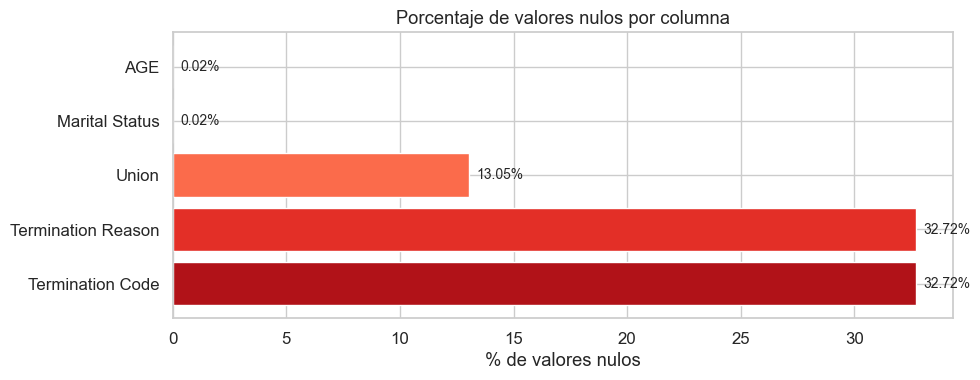

In [8]:
# --- Valores nulos ---
nulls = df.isnull().sum()
nulls_pct = (nulls / len(df) * 100).round(2)

null_df = pd.DataFrame({
    'Nulos': nulls,
    'Porcentaje (%)': nulls_pct,
    'Tipo': df.dtypes.astype(str)
}).sort_values('Porcentaje (%)', ascending=False)

print(f'Columnas sin nulos: {(nulls == 0).sum()} / {len(nulls)}')
print(f'Columnas con al menos 1 nulo: {(nulls > 0).sum()} / {len(nulls)}')
print()
print('--- Detalle de columnas con nulos ---')
display(null_df[null_df['Nulos'] > 0])

# Gráfico
fig, ax = plt.subplots(figsize=(10, 4))
cols_con_nulos = null_df[null_df['Nulos'] > 0]
bars = ax.barh(cols_con_nulos.index, cols_con_nulos['Porcentaje (%)'], color=sns.color_palette('Reds_r', len(cols_con_nulos)))
ax.set_xlabel('% de valores nulos')
ax.set_title('Porcentaje de valores nulos por columna')
for bar, val in zip(bars, cols_con_nulos['Porcentaje (%)']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}%', va='center', fontsize=10)
plt.tight_layout()
plt.show()

In [9]:
# --- Duplicados ---
dupes_total = df.duplicated().sum()
dupes_emp   = df.duplicated(subset='Employee Code').sum()

print(f'Filas duplicadas (todas las columnas): {dupes_total}')
print(f'Employee Codes duplicados:             {dupes_emp}')
print(f'Employee Codes únicos:                 {df["Employee Code"].nunique():,} / {len(df):,}')

Filas duplicadas (todas las columnas): 0
Employee Codes duplicados:             0
Employee Codes únicos:                 5,792 / 5,792


In [10]:
# Únicos de cada columna
cardinality = pd.DataFrame({
    'Valores únicos': df.nunique(),
    '% únicos': (df.nunique() / len(df) * 100).round(2),
    'Tipo': df.dtypes,
    'Muestra': [str(df[c].dropna().unique()[:5].tolist()) for c in df.columns]
}).sort_values('Valores únicos', ascending=False)

print('CANTIDAD VALORES ÚNICOS POR COLUMNA')
print('='*60)
cardinality

CANTIDAD VALORES ÚNICOS POR COLUMNA


,Valores únicos,% únicos,Tipo,Muestra
Employee Code,5792,100.0000,object,"['EMP_00001', 'EMP_00002', 'EMP_00003', 'EMP_0..."
Termination Date,2123,36.6500,object,"[datetime.datetime(2013, 9, 27, 0, 0), datetim..."
Hire Date,1634,28.2100,datetime64[ns],"[Timestamp('2011-06-20 00:00:00'), Timestamp('..."
Exchange Rate,1484,25.6200,float64,"[3001.5, 3765.92, 3698.6, 2987.57, 3088.44]"
Standardized_Salary,842,14.5400,float64,"[0.1996017650088621, 0.12028951686917123, 0.22..."
Position vs Estimated Median,706,12.1900,float64,"[0.9123698041863606, 0.828, 0.9123694800810264..."
Supervisor Code,354,6.1100,object,"['Inactive', 'EMP_01989', 'EMP_00185', 'EMP_00..."
Employee Job ID,341,5.8900,object,"['Cargo 1', 'Cargo 2', 'Cargo 3', 'Cargo 4', '..."
Cantidad Salarios Minimos,147,2.5400,int64,"[66, 24, 65, 30, 37]"
Supervisor Job ID,130,2.2400,object,"['Cargo 342', 'Cargo 37', 'Cargo 13', 'Cargo 9..."


---
## 4. Análisis variable por variable (las 40 columnas)

Se documenta cada variable: tipo, distribución, observaciones y relevancia para el modelo.

Variable 1: Employee Code: No aporta valor predictivo — es una llave primaria. Podría usarse para calcular el número de jefes distintos, pero no como feature directa.

Variable 2: Termination Code: 
→ Altamente correlacionado con Termination Reason. Puede descartarse si se usa Termination Reason.
→ NaN indica empleado activo (dato implícito, no faltante real).

VARIABLE 3 — Hours/Week
             count
Hours/ Week       
48            2932
44            2018
46             356
47             333
24             110
23              22
22              10
0                8
36               1
8                1
40               1

  Media: 45.8 | Mín: 0 | Máx: 48


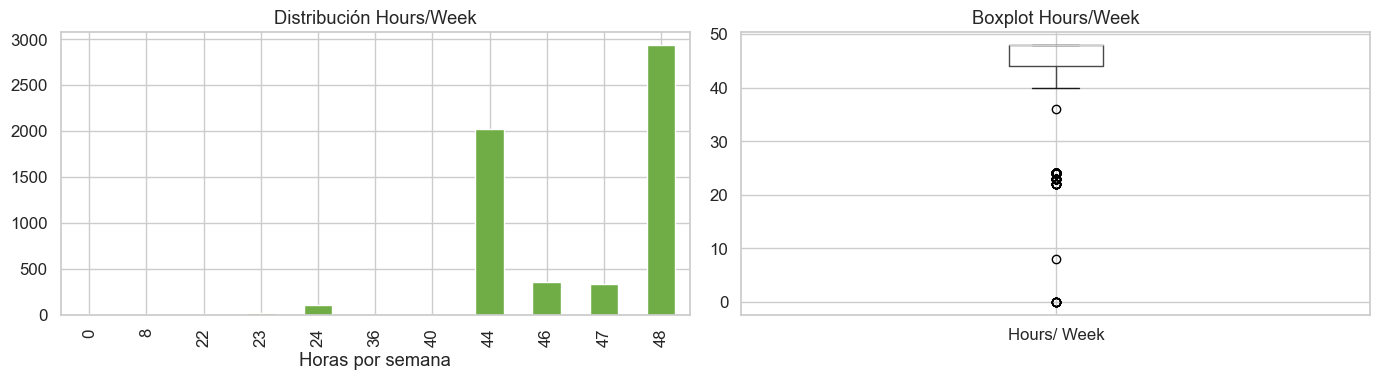

In [11]:
# ── Variable 3: Hours/Week ─────────────────────────────────────────────────
print('VARIABLE 3 — Hours/Week')
print(df['Hours/ Week'].value_counts().to_frame('count'))
print()
print(f'  Media: {df["Hours/ Week"].mean():.1f} | Mín: {df["Hours/ Week"].min()} | Máx: {df["Hours/ Week"].max()}')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df['Hours/ Week'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='#70ad47')
axes[0].set_title('Distribución Hours/Week')
axes[0].set_xlabel('Horas por semana')
df.boxplot(column='Hours/ Week', ax=axes[1])
axes[1].set_title('Boxplot Hours/Week')
plt.tight_layout()
plt.show()

Variable 3: Los que tienen horas en 0, son errores en datos, se debe revisar que acción se va a tomar, los del rango inferior a 44, se debe revisar que sean personas part time, de lo contrario, tambien seria error en el registro y debe tratarse

Variable 4: Currency Code: Desde la abse se dejaron todos los registros en moneda local COP, por lo que hay un error en las monedas que parecen como USD, seria una variable a eliminar porque seria única, no aporta valor, es la misma para todos

VARIABLES 5, 6, 7 — Niveles de Inglés (Reading, Spoken, Writing)
       English Reading Lvl  English Spoken Lvl  English Writing Lvl
count            5792.0000           5792.0000            5792.0000
mean                0.6221              0.6117               0.6269
std                 1.2394              1.2289               1.2477
min                 0.0000              0.0000               0.0000
25%                 0.0000              0.0000               0.0000
50%                 0.0000              0.0000               0.0000
75%                 1.0000              1.0000               1.0000
max                 4.0000              4.0000               4.0000


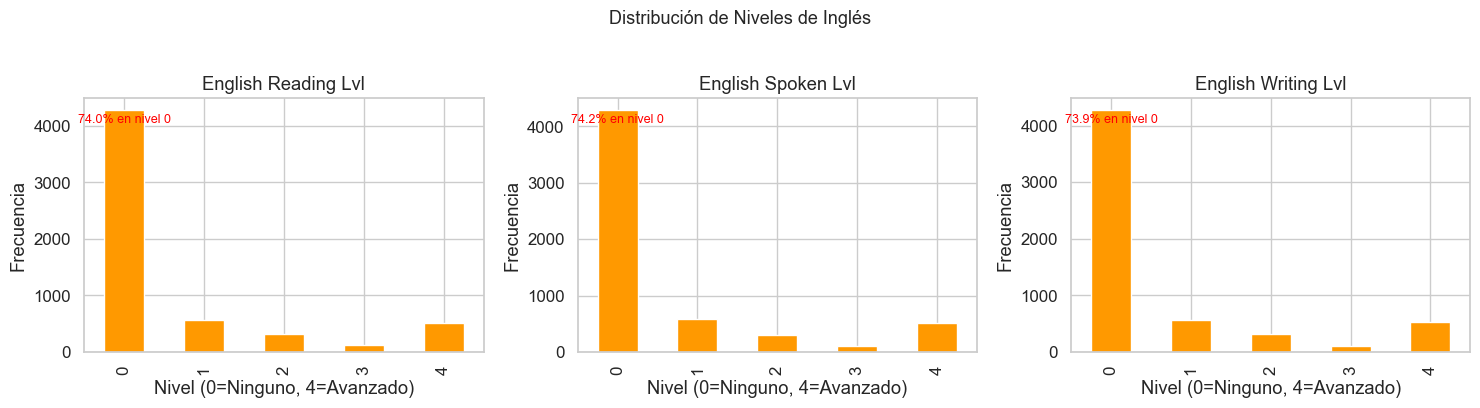

In [12]:
# ── Variables 5-7: Niveles de inglés ──────────────────────────────────────
english_cols = ['English Reading Lvl', 'English Spoken Lvl', 'English Writing Lvl']

print('VARIABLES 5, 6, 7 — Niveles de Inglés (Reading, Spoken, Writing)')
print(df[english_cols].describe())

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, english_cols):
    df[col].value_counts().sort_index().plot(kind='bar', ax=ax, color='#ff9900')
    ax.set_title(col)
    ax.set_xlabel('Nivel (0=Ninguno, 4=Avanzado)')
    pct_cero = (df[col] == 0).mean() * 100
    ax.set_ylabel('Frecuencia')
    ax.annotate(f'{pct_cero:.1f}% en nivel 0', xy=(0, ax.get_ylim()[1]*0.9), ha='center', fontsize=9, color='red')
plt.suptitle('Distribución de Niveles de Inglés', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()


Variables 5-7: Niveles de inglés
→ Alta correlación entre las 3 variables → considerar crear un índice compuesto: english_score.
→ Mayoría en nivel 0 (empresa hispanohablante) → baja varianza predictiva por sí solas.

VARIABLES 8, 9, 10 — Niveles de Español (Reading, Spoken, Writing)
       Spanish Reading Lvl  Spanish Spoken Lvl  Spanish Writing Lvl
count            5792.0000           5792.0000            5792.0000
mean                3.0570              3.0566               3.0471
std                 1.6872              1.6875               1.6919
min                 0.0000              0.0000               0.0000
25%                 4.0000              4.0000               4.0000
50%                 4.0000              4.0000               4.0000
75%                 4.0000              4.0000               4.0000
max                 4.0000              4.0000               4.0000


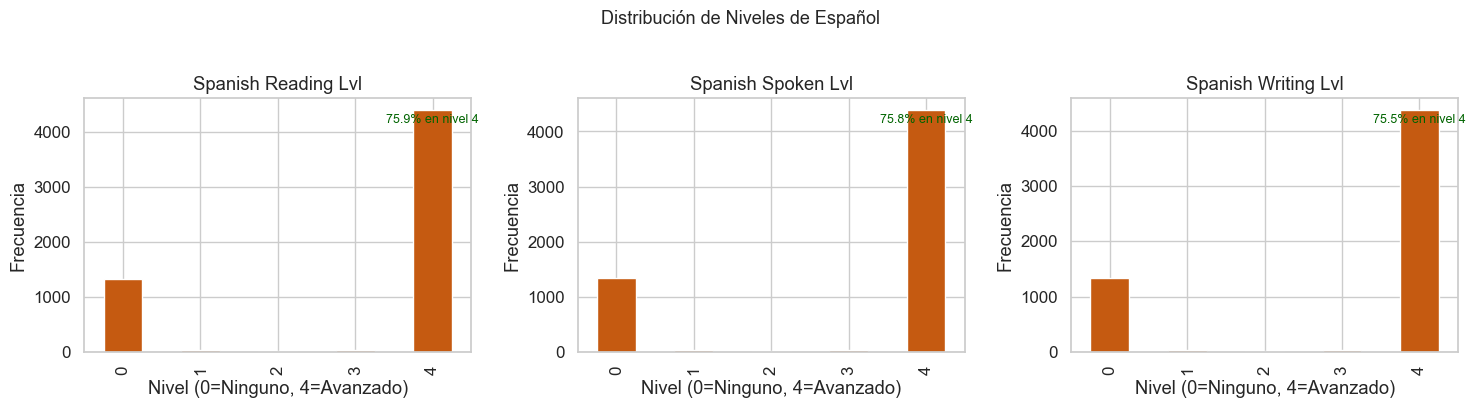

In [13]:
# ── Variables 8-10: Niveles de español ────────────────────────────────────
spanish_cols = ['Spanish Reading Lvl', 'Spanish Spoken Lvl', 'Spanish Writing Lvl']

print('VARIABLES 8, 9, 10 — Niveles de Español (Reading, Spoken, Writing)')
print(df[spanish_cols].describe())

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, spanish_cols):
    df[col].value_counts().sort_index().plot(kind='bar', ax=ax, color='#c55a11')
    ax.set_title(col)
    ax.set_xlabel('Nivel (0=Ninguno, 4=Avanzado)')
    pct_cuatro = (df[col] == 4).mean() * 100
    ax.set_ylabel('Frecuencia')
    ax.annotate(f'{pct_cuatro:.1f}% en nivel 4', xy=(4, ax.get_ylim()[1]*0.9), ha='center', fontsize=9, color='darkgreen')
plt.suptitle('Distribución de Niveles de Español', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()


Variables 8-10: Niveles de español

→ Altísima correlación inter-variable → crear índice compuesto: spanish_score.
→ Mayoría en nivel 4 (empresa en Colombia) → baja varianza individual, creo que no aporta mucho valor al modelo, entonces podriamos quitarlo, hay gente que no tiene buen nivel de español, porque son personas de otras nacionalidades, pero en su mayoria se trata de personas que dominan el idioma, creo que puede ser más interesante el dominar el inglés que el español

In [14]:
# ── Variable 11: Union ────────────────────────────────────────────────────
print('VARIABLE 11 — Union')
print(df['Union'].value_counts(dropna=False))
print()


VARIABLE 11 — Union
Union
N      5030
NaN     756
Y         5
X         1
Name: count, dtype: int64



Variable 11: Union 
"N": significa que no están en el sindicanto y representa el 99.9% de los registros con valor.
Nulos: 756 (13.1%)
Varianza extremadamente baja (casi todos "N") → candidata a eliminación.

VARIABLE 12 — Employee Job ID
  Únicos: 341
  Top 10:
Employee Job ID
Cargo 31    621
Cargo 39    462
Cargo 17    440
Cargo 29    201
Cargo 36    180
Cargo 6     174
Cargo 43    148
Cargo 38    137
Cargo 15    128
Cargo 64    121
Name: count, dtype: int64


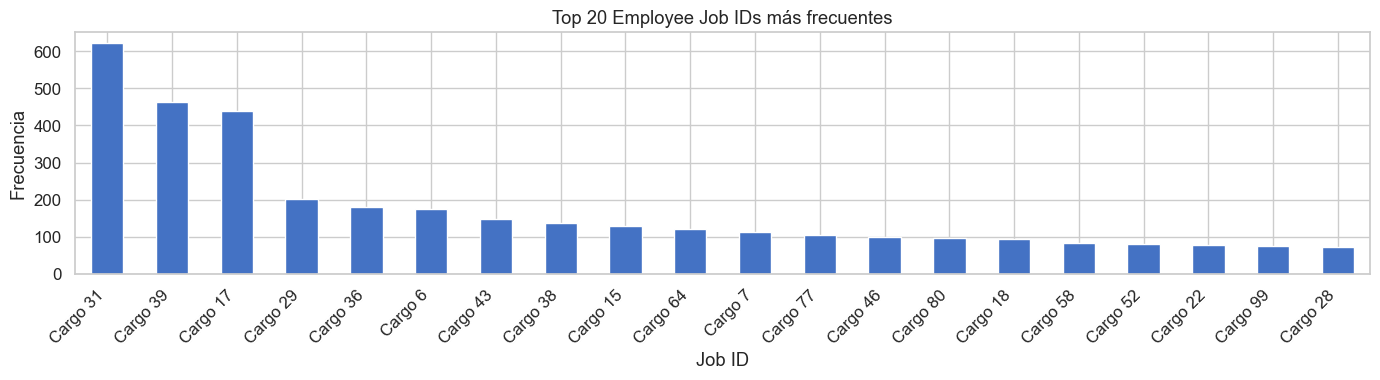

In [15]:
# ── Variable 12: Employee Job ID ──────────────────────────────────────────
print('VARIABLE 12 — Employee Job ID')
print(f'  Únicos: {df["Employee Job ID"].nunique()}')
print(f'  Top 10:')
print(df['Employee Job ID'].value_counts().head(10))

fig, ax = plt.subplots(figsize=(14, 4))
top_jobs = df['Employee Job ID'].value_counts().head(20)
top_jobs.plot(kind='bar', ax=ax, color='#4472c4')
ax.set_title('Top 20 Employee Job IDs más frecuentes')
ax.set_xlabel('Job ID')
ax.set_ylabel('Frecuencia')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print()

Variable 12: Employee Job ID: Este se refiere a los diferentes cargos que existen en la empresa, por temas de confidencialidad se codificaron, por ejemplo cajero ahora aparece como Cargo 31, por decir algo.
→ Alta cantidad de valores únicos (341 cargos). Revisar si quizá pueda agruparse con otra variable por ejemplo segun el departamento
→ Podría codificarse con target encoding o frecuency encoding

VARIABLE 13 — Gender
Gender
Male       3482
Female     2289
Unknown      21
Name: count, dtype: int64


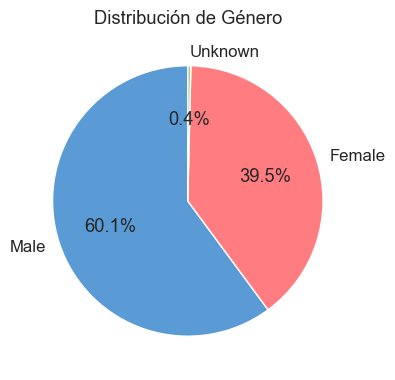

In [16]:
# ── Variable 13: Gender ───────────────────────────────────────────────────
print('VARIABLE 13 — Gender')
print(df['Gender'].value_counts(dropna=False))

fig, ax = plt.subplots(figsize=(6, 4))
vals = df['Gender'].value_counts()
ax.pie(vals, labels=vals.index, autopct='%1.1f%%', startangle=90,
       colors=['#5b9bd5', '#ff7c80', '#a9d18e'])
ax.set_title('Distribución de Género')
plt.tight_layout()
plt.show()

Variable 13: Gender 
  21 registros "Unknown" (0.36%) → revisar si hay que imputar o mantener como categoría.
  → Variable relevante para análisis de equidad y para el modelo.

VARIABLE 14 — Marital Status
Marital Status
Single        3510
Free Union    1105
Married        792
Common Law     173
Unknown        126
Divorced        77
Widowed          5
Partner          3
NaN              1
Name: count, dtype: int64


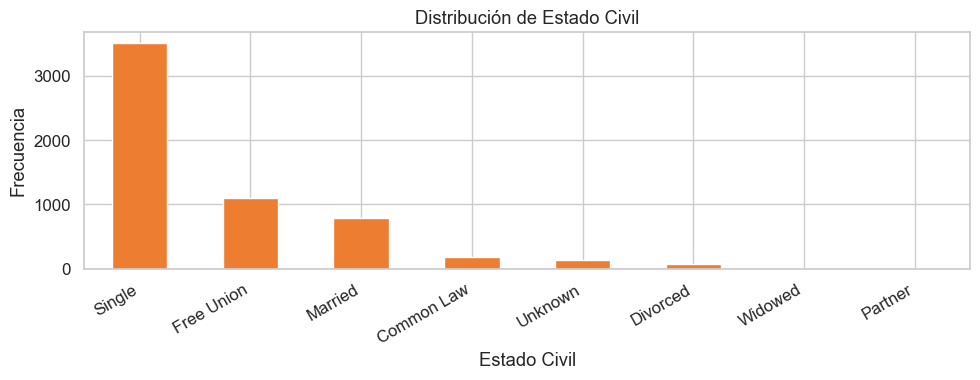

In [17]:
# ── Variable 14: Marital Status ───────────────────────────────────────────
print('VARIABLE 14 — Marital Status')
print(df['Marital Status'].value_counts(dropna=False))

fig, ax = plt.subplots(figsize=(10, 4))
df['Marital Status'].value_counts().plot(kind='bar', ax=ax, color='#ed7d31')
ax.set_title('Distribución de Estado Civil')
ax.set_xlabel('Estado Civil')
ax.set_ylabel('Frecuencia')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

print()


Variable 14: Marital Status
→ "Common Law" y "Free Union" son similares jurídicamente; considerar unificar.
→ 1 nulo → imputar con moda o categoría "Unknown".

VARIABLES 15, 16 — Area y Grouped Department Name


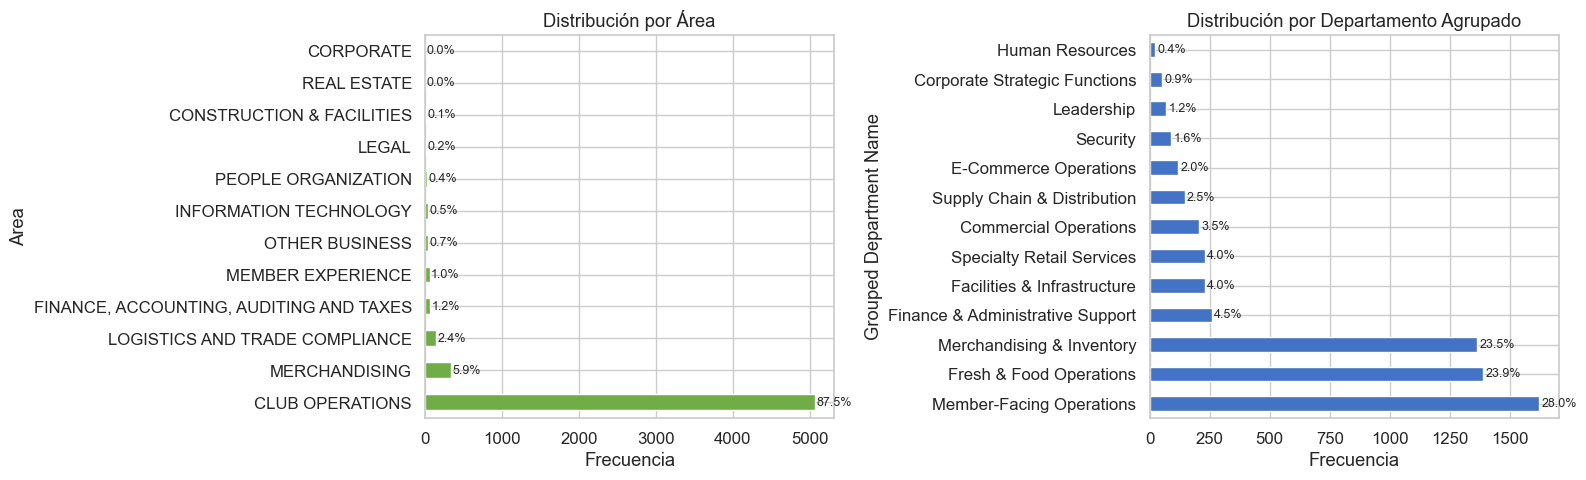

In [18]:
# ── Variables 15-16: Area y Grouped Department Name ──────────────────────
print('VARIABLES 15, 16 — Area y Grouped Department Name')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

area_counts = df['Area'].value_counts()
area_counts.plot(kind='barh', ax=axes[0], color='#70ad47')
axes[0].set_title('Distribución por Área')
axes[0].set_xlabel('Frecuencia')
for i, v in enumerate(area_counts):
    axes[0].text(v + 20, i, f'{v/len(df)*100:.1f}%', va='center', fontsize=9)

dept_counts = df['Grouped Department Name'].value_counts()
dept_counts.plot(kind='barh', ax=axes[1], color='#4472c4')
axes[1].set_title('Distribución por Departamento Agrupado')
axes[1].set_xlabel('Frecuencia')
for i, v in enumerate(dept_counts):
    axes[1].text(v + 10, i, f'{v/len(df)*100:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print()

VARIABLE 17 — Job Level
Job Level
1     1244
2     1739
3      739
4      767
5      645
6      162
7      351
8       69
9       26
10      34
11      10
12       2
13       2
15       1
16       1
Name: count, dtype: int64


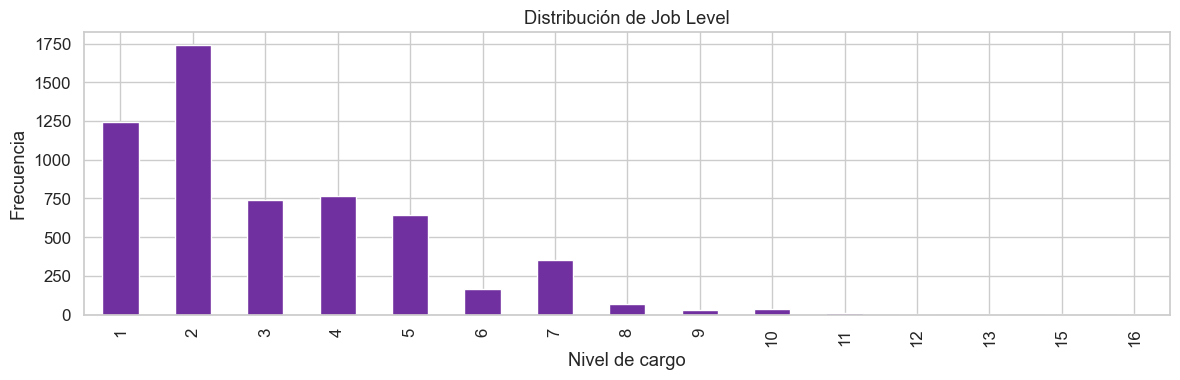

In [19]:
# ── Variable 17: Job Level ────────────────────────────────────────────────
print('VARIABLE 17 — Job Level')
print(df['Job Level'].value_counts().sort_index())

fig, ax = plt.subplots(figsize=(12, 4))
df['Job Level'].value_counts().sort_index().plot(kind='bar', ax=ax, color='#7030a0')
ax.set_title('Distribución de Job Level')
ax.set_xlabel('Nivel de cargo')
ax.set_ylabel('Frecuencia')
plt.tight_layout()
plt.show()


 Variable 17: Job Level
 puede llegar a ser muy importante en el modelo (nivel de cargo vs rotación). Se puede considerar agruar bajo categorias de técnico, tecnologo, profesional, jefes, etc.

VARIABLES 18, 19 — Location Description y Type Location


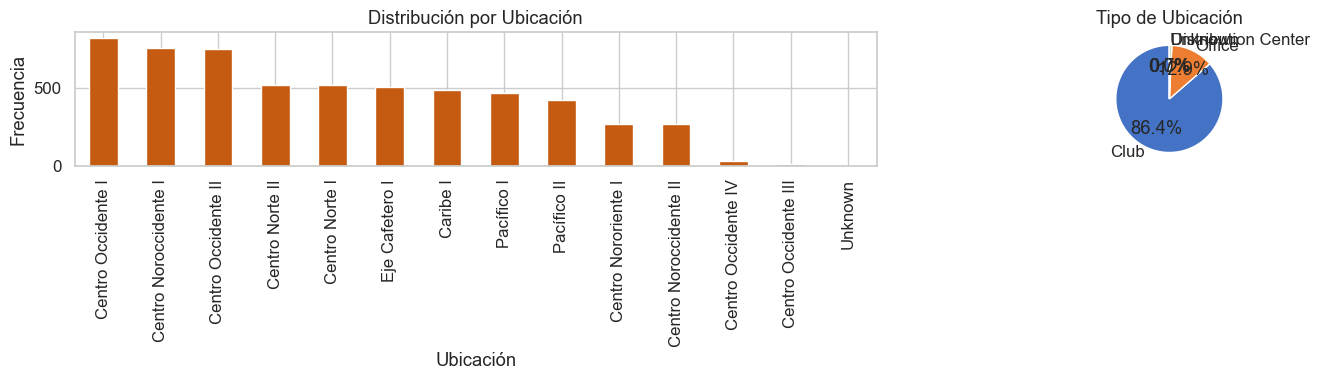

Type Location        Type   
Club                 C          5003
Distribution Center  D            42
Office               O           746
Unknown              Unknown       1


In [20]:
# ── Variables 18-19: Location Description y Type Location ─────────────────
print('VARIABLES 18, 19 — Location Description y Type Location')

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

loc_counts = df['Location Description'].value_counts()
loc_counts.plot(kind='bar', ax=axes[0], color='#c55a11')
axes[0].set_title('Distribución por Ubicación')
axes[0].set_xlabel('Ubicación')
axes[0].set_ylabel('Frecuencia')

type_loc_counts = df['Type Location'].value_counts()
axes[1].pie(type_loc_counts, labels=type_loc_counts.index,
            autopct='%1.1f%%', startangle=90,
            colors=['#4472c4', '#ed7d31', '#a9d18e', '#ffc000'])
axes[1].set_title('Tipo de Ubicación')

plt.tight_layout()
plt.show()

print(df.groupby('Type Location')['Type'].value_counts().to_string())

Variables 18-19: Location Description y Type Location
→ Type Location y la columna "Type" son redundantes (C=Club, O=Office, D=Distribution).
→ Verificar cruce

VARIABLE 20 — Contract Type
Contract Type
Full Time    5590
Part Time     202
Name: count, dtype: int64

VARIABLE 21 — Exchange Rate (TRM USD/COP)
count   5792.0000
mean    3695.4444
std      457.4823
min     2705.7500
25%     3421.0550
50%     3765.9200
75%     3909.5125
max     5104.0000
Name: Exchange Rate, dtype: float64


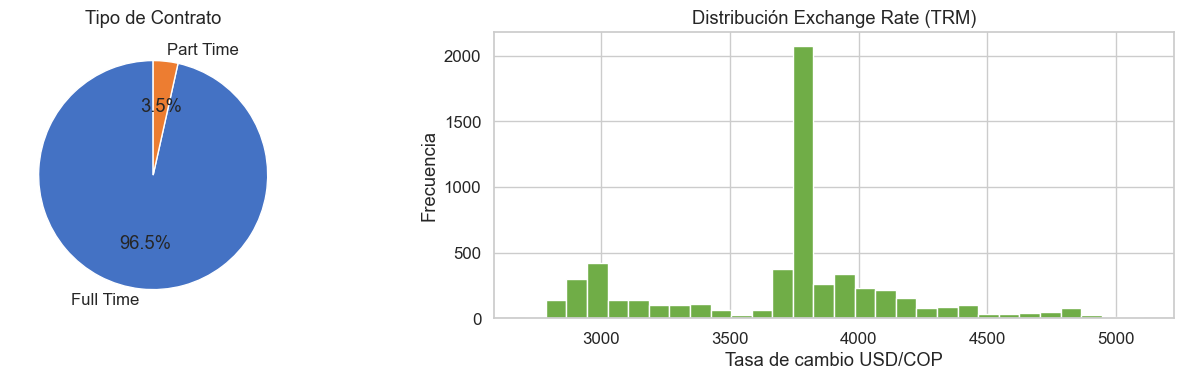

In [21]:
# ── Variables 20-21: Contract Type y Exchange Rate ─────────────────────────
print('VARIABLE 20 — Contract Type')
print(df['Contract Type'].value_counts())
print()
print('VARIABLE 21 — Exchange Rate (TRM USD/COP)')
print(df['Exchange Rate'].describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ct_counts = df['Contract Type'].value_counts()
axes[0].pie(ct_counts, labels=ct_counts.index, autopct='%1.1f%%', startangle=90,
            colors=['#4472c4', '#ed7d31'])
axes[0].set_title('Tipo de Contrato')

df['Exchange Rate'].hist(bins=30, ax=axes[1], color='#70ad47', edgecolor='white')
axes[1].set_title('Distribución Exchange Rate (TRM)')
axes[1].set_xlabel('Tasa de cambio USD/COP')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()


Variables 20-21: Contract Type y Exchange Rate
Contract Type: mayoría Full Time (96.5%).
Exchange Rate: varía entre 2,700 y 5,100 → refleja cambio en el tiempo (ligado a Hire Date)
→ Exchange Rate = TRM a la fecha de contratación; correlacionada con Hire Date.

VARIABLE 22 — Type
Type
C          5003
O           746
D            42
Unknown       1
Name: count, dtype: int64

VARIABLE 23 — Termination Reason
  Nulos: 1895 (empleados activos)
Termination Reason
Better Job Opp (Voluntary)        663
Other **EXPLAIN IN COMMENTS**     407
Family (Voluntary)                399
Personal** DO NOT USE** (Vol)     367
Violation of Policy (Involun)     296
Reduction in Force (Involun)      283
Unable to meet job requirement    275
Unwilling to meet job req.        205
Unwilling to meet req (Inv)       169
Relocation(Voluntary)             152
Insubordination (Involuntary)     123
Unknown (Voluntary)               108
School (Voluntary)                 83
Boredom (Voluntary)                71
Work Environment (Voluntary)       55
Name: count, dtype: int64

VARIABLE 24 — Termination Type
Termination Type
Voluntary      2021
Unknown        1895
Involuntary    1876
Name: count, dtype: int64


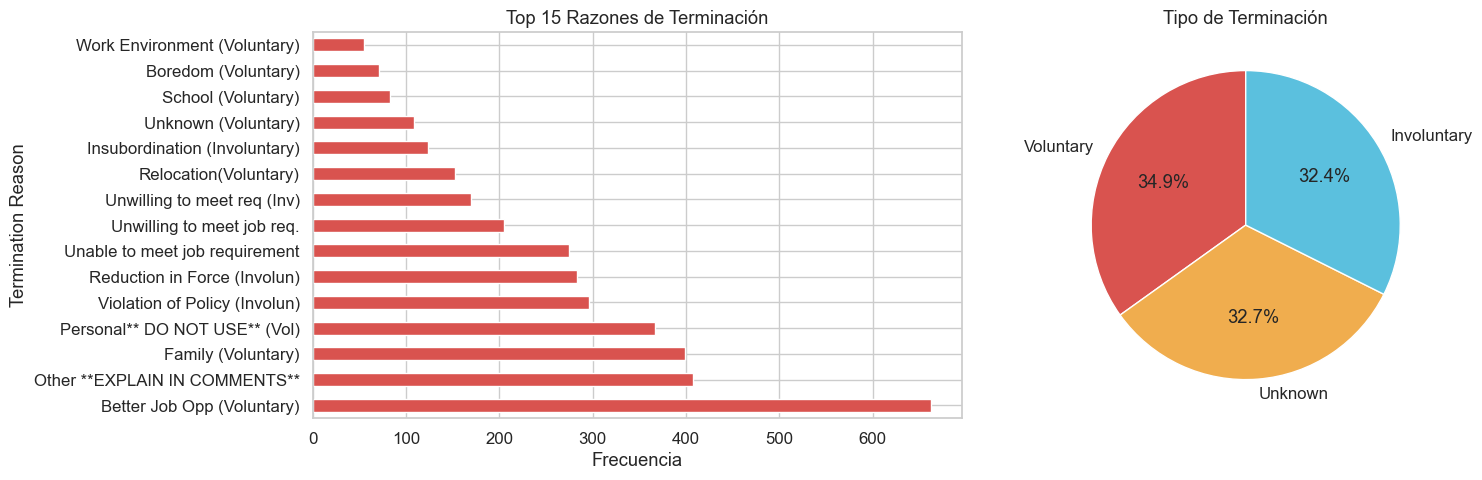

In [22]:
# ── Variables 22-24: Type, Termination Reason, Termination Type ──────────
print('VARIABLE 22 — Type')
print(df['Type'].value_counts())
print()
print('VARIABLE 23 — Termination Reason')
print(f'  Nulos: {df["Termination Reason"].isnull().sum()} (empleados activos)')
print(df['Termination Reason'].value_counts().head(15))
print()
print('VARIABLE 24 — Termination Type')
print(df['Termination Type'].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Termination Reason - solo retirados
term_reason = df[df['Termination Reason'].notna()]['Termination Reason'].value_counts().head(15)
term_reason.plot(kind='barh', ax=axes[0], color='#d9534f')
axes[0].set_title('Top 15 Razones de Terminación')
axes[0].set_xlabel('Frecuencia')

# Termination Type
tt_counts = df['Termination Type'].value_counts()
axes[1].pie(tt_counts, labels=tt_counts.index, autopct='%1.1f%%', startangle=90,
            colors=['#d9534f', '#f0ad4e', '#5bc0de'])
axes[1].set_title('Tipo de Terminación')

plt.tight_layout()
plt.show()

Variables 22-24: Type, Termination Reason, Termination Type
"Unknown" en Termination Type = empleados activos (1,895 registros).')
→ Termination Reason tiene 34 categorías — agrupar en: Voluntaria, Involuntaria, Desconocida.')
→ "Type" (C/O/D/Unknown) duplica Type Location → candidata a eliminación.')

VARIABLE 25 — Target Bonus %
count   5792.0000
mean       0.0043
std        0.0271
min        0.0000
25%        0.0000
50%        0.0000
75%        0.0000
max        0.3000
Name: Target Bonus %, dtype: float64
  Cero: 5647 registros (97.5%)

VARIABLE 30 — Target Equity %
count   5792.0000
mean       0.0017
std        0.0159
min        0.0000
25%        0.0000
50%        0.0000
75%        0.0000
max        0.4000
Name: Target Equity %, dtype: float64
  Cero: 5716 registros (98.7%)


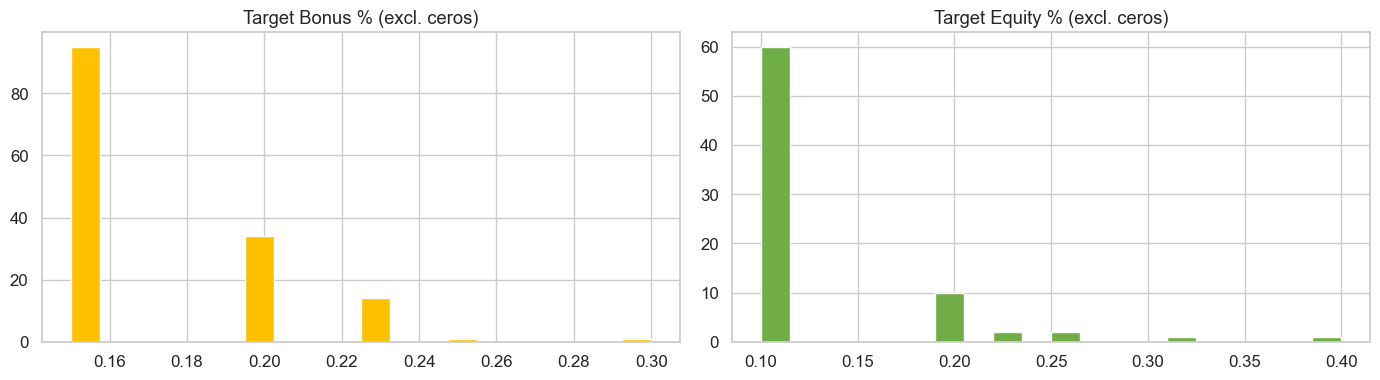

In [23]:
# ── Variables 25, 30: Target Bonus % y Target Equity % ───────────────────
print('VARIABLE 25 — Target Bonus %')
print(df['Target Bonus %'].describe())
print(f'  Cero: {(df["Target Bonus %"] == 0).sum()} registros ({(df["Target Bonus %"] == 0).mean()*100:.1f}%)')
print()
print('VARIABLE 30 — Target Equity %')
print(df['Target Equity %'].describe())
print(f'  Cero: {(df["Target Equity %"] == 0).sum()} registros ({(df["Target Equity %"] == 0).mean()*100:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df[df['Target Bonus %'] > 0]['Target Bonus %'].hist(bins=20, ax=axes[0], color='#ffc000', edgecolor='white')
axes[0].set_title('Target Bonus % (excl. ceros)')
df[df['Target Equity %'] > 0]['Target Equity %'].hist(bins=20, ax=axes[1], color='#70ad47', edgecolor='white')
axes[1].set_title('Target Equity % (excl. ceros)')
plt.tight_layout()
plt.show()


Variables 25, 30: Target Bonus % y Target Equity %: Se refiere al % de bono anual que recibiria una persona si aplica (Target bonus) y al % de bono variable de una persona si aplica.
→ Crear variables binarias: has_bonus y has_equity para mejor representación.

VARIABLE 26 — Non Exempt (exento de horas extras)
Non Exempt
Non Exempt    2905
Exempt        2887
Name: count, dtype: int64

VARIABLE 27 — Active Employee (VARIABLE OBJETIVO)
Active Employee
N    3897
Y    1895
Name: count, dtype: int64
  Tasa de rotación: 67.3%


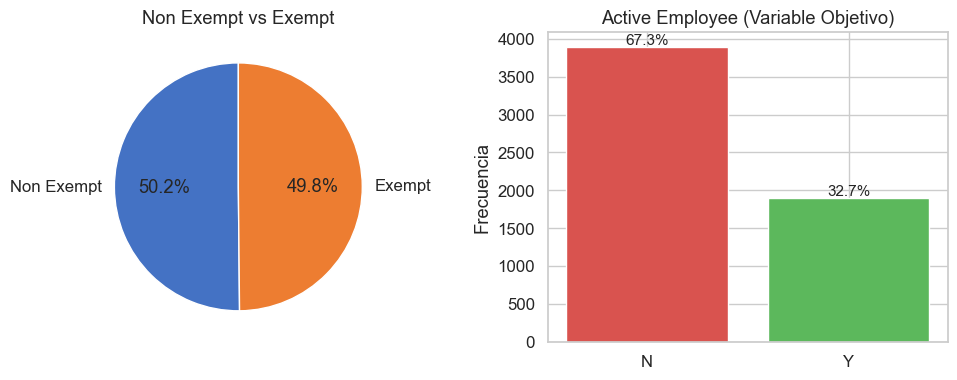

In [24]:
# ── Variables 26, 27: Non Exempt y Active Employee ─────────────────────────
print('VARIABLE 26 — Non Exempt (exento de horas extras)')
print(df['Non Exempt'].value_counts())
print()
print('VARIABLE 27 — Active Employee (VARIABLE OBJETIVO)')
print(df['Active Employee'].value_counts())
print(f'  Tasa de rotación: {(df["Active Employee"] == "N").mean()*100:.1f}%')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ne_counts = df['Non Exempt'].value_counts()
axes[0].pie(ne_counts, labels=ne_counts.index, autopct='%1.1f%%', startangle=90,
            colors=['#4472c4', '#ed7d31'])
axes[0].set_title('Non Exempt vs Exempt')

ae_counts = df['Active Employee'].value_counts()
axes[1].bar(ae_counts.index, ae_counts.values, color=['#d9534f', '#5cb85c'])
axes[1].set_title('Active Employee (Variable Objetivo)')
axes[1].set_ylabel('Frecuencia')
for i, (k, v) in enumerate(ae_counts.items()):
    axes[1].text(i, v + 30, f'{v/len(df)*100:.1f}%', ha='center', fontsize=11)

plt.tight_layout()
plt.show()

Variables 26, 27: Non Exempt y Active Employee
→ Active Employee = N: son los que han rotado
→ Dataset con clases relativamente balanceadas.

En cuantyo a Exempt y Non Exempt, se refiere a si las personas está habilitadas para generar horas extras y recibir pago de ello

VARIABLE 28 — Hire Date
  Rango: 1998-11-02 a 2025-12-19
  Tipo: datetime64[ns]

VARIABLE 29 — Termination Date
  Tipo raw: object
  Valores únicos (muestra): [datetime.datetime(2013, 9, 27, 0, 0) datetime.time(0, 0)
 datetime.datetime(2014, 8, 27, 0, 0) datetime.datetime(2013, 4, 15, 0, 0)
 datetime.datetime(2015, 7, 9, 0, 0) datetime.datetime(2014, 10, 15, 0, 0)
 datetime.datetime(2014, 2, 18, 0, 0) datetime.datetime(2013, 6, 1, 0, 0)
 datetime.datetime(2013, 7, 22, 0, 0) datetime.datetime(2014, 2, 15, 0, 0)]
  Nulos tras conversión: 1895


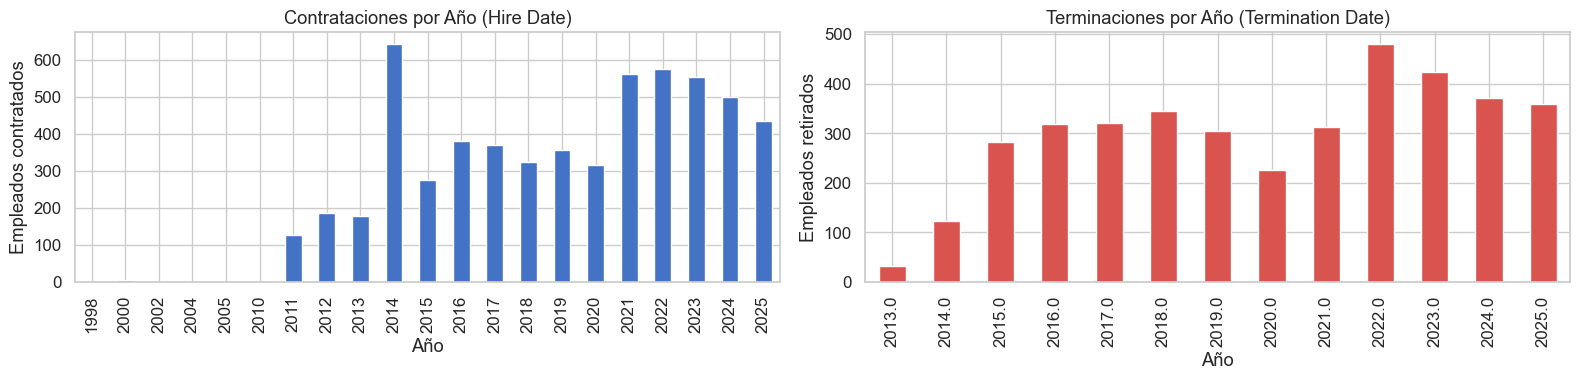

In [25]:
# ── Variables 28, 29: Hire Date y Termination Date ────────────────────────
print('VARIABLE 28 — Hire Date')
print(f'  Rango: {df["Hire Date"].min().date()} a {df["Hire Date"].max().date()}')
print(f'  Tipo: {df["Hire Date"].dtype}')

print()
print('VARIABLE 29 — Termination Date')
print(f'  Tipo raw: {df["Termination Date"].dtype}')
print(f'  Valores únicos (muestra): {df["Termination Date"].unique()[:10]}')

# Convertir Termination Date
df['Termination Date Clean'] = pd.to_datetime(df['Termination Date'], errors='coerce')
# Valores que son solo hora '00:00:00' corresponden a empleados activos
print(f'  Nulos tras conversión: {df["Termination Date Clean"].isnull().sum()}')

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

df['Hire Date'].dt.year.value_counts().sort_index().plot(kind='bar', ax=axes[0], color='#4472c4')
axes[0].set_title('Contrataciones por Año (Hire Date)')
axes[0].set_xlabel('Año')
axes[0].set_ylabel('Empleados contratados')

df['Termination Date Clean'].dt.year.value_counts().sort_index().plot(kind='bar', ax=axes[1], color='#d9534f')
axes[1].set_title('Terminaciones por Año (Termination Date)')
axes[1].set_xlabel('Año')
axes[1].set_ylabel('Empleados retirados')

plt.tight_layout()
plt.show()


Variables 28, 29: Hire Date y Termination Date
→ Hire Date está limpio (datetime64). Termination Date tiene mezcla de fechas y timestamps vacíos.
→ Ambas son clave para calcular ANTIGÜEDAD. y si pasó o no el periodo de prueba, hau una vaiable que lo indica, pero se debe validar que esté boien (periodo de prueba 2 meses)

VARIABLE 31 — Standardized_Salary
count   5792.0000
mean      -0.0000
std        1.0000
min       -0.5753
25%       -0.3630
50%       -0.2107
75%       -0.0552
max       20.7953
Name: Standardized_Salary, dtype: float64

  Media ≈ 0, Std ≈ 1 → ya está estandarizada (Z-score).
  Mínimo: -0.575 | Máximo: 20.795
  Outliers (|z| > 3): 98 registros


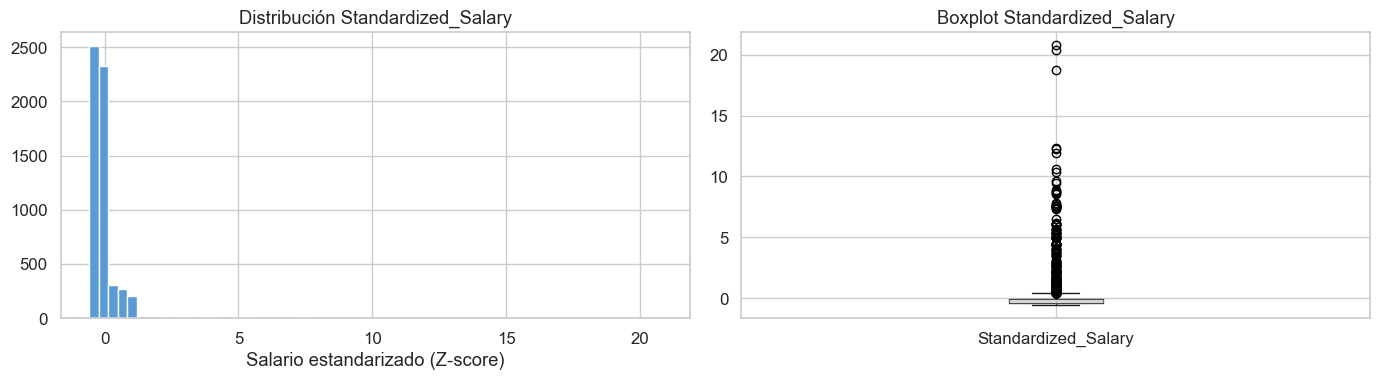

In [26]:
# ── Variable 31: Standardized_Salary ──────────────────────────────────────
print('VARIABLE 31 — Standardized_Salary')
print(df['Standardized_Salary'].describe())
print()
print(f'  Media ≈ 0, Std ≈ 1 → ya está estandarizada (Z-score).')
print(f'  Mínimo: {df["Standardized_Salary"].min():.3f} | Máximo: {df["Standardized_Salary"].max():.3f}')
print(f'  Outliers (|z| > 3): {(df["Standardized_Salary"].abs() > 3).sum()} registros')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df['Standardized_Salary'].hist(bins=60, ax=axes[0], color='#5b9bd5', edgecolor='white')
axes[0].set_title('Distribución Standardized_Salary')
axes[0].set_xlabel('Salario estandarizado (Z-score)')
df.boxplot(column='Standardized_Salary', ax=axes[1])
axes[1].set_title('Boxplot Standardized_Salary')
plt.tight_layout()
plt.show()


Variable 31: Standardized_Salary
→ Distribución sesgada a la derecha (unos pocos ejecutivos con salarios muy altos).
→ Variable predictiva clave: salario relativo vs rotación.

In [27]:
# ── Variables 32-35: Datos del Supervisor ────────────────────────────────
print('VARIABLES 32-35 — Supervisor (Active Supervisor, Code, Dept, Job ID)')
print()
print('Active Supervisor:')
print(df['Active Supervisor'].value_counts())
print()
print('Supervisor Code (top 10):')
print(df['Supervisor Code'].value_counts().head(10))
print()
print('Gropued Supervisor Department:')
print(df['Gropued Supervisor Department'].value_counts())
print()
print('Supervisor Job ID (top 10):')
print(df['Supervisor Job ID'].value_counts().head(10))


VARIABLES 32-35 — Supervisor (Active Supervisor, Code, Dept, Job ID)

Active Supervisor:
Active Supervisor
Y    3924
N    1868
Name: count, dtype: int64

Supervisor Code (top 10):
Supervisor Code
Inactive     1868
EMP_01768     113
EMP_01553      84
EMP_02410      72
EMP_00980      67
EMP_01352      64
EMP_00013      59
EMP_00185      59
EMP_00431      58
EMP_01000      56
Name: count, dtype: int64

Gropued Supervisor Department:
Gropued Supervisor Department
Inactive                            1868
Member-Facing Operations             749
Leadership                           739
Merchandising & Inventory            664
Fresh & Food Operations              644
Finance & Administrative Support     229
Other / Non-Operational              222
Commercial Operations                194
Supply Chain & Distribution          117
Facilities & Infrastructure           96
Corporate Strategic Functions         89
Specialty Retail Services             53
E-Commerce Operations                 50
Hum

Variables 32-35: Datos del Supervisor
→ Supervisor Code tiene valor "Inactive" cuando el supervisor ya no está activo (1,868 casos).
→ Active Supervisor Y/N puede ser relevante: tener un jefe activo vs. inactivo.
→ Supervisor Code tiene alta cardinalidad (354 únicos) — usar Active Supervisor o Dept del supervisor.

In [28]:
# ── Variable 36: Probation Period Completed ───────────────────────────────
print('VARIABLE 36 — Probation Period Completed')
print(df['Probation Period Completed'].value_counts())
pct_yes = (df['Probation Period Completed'] == 'Yes').mean() * 100


VARIABLE 36 — Probation Period Completed
Probation Period Completed
Yes    5743
No       49
Name: count, dtype: int64


Variable 36: Probation Period Completed
Esta es la variable que idgo que hay que revisar con detalle, a partir de la fecha de contratación y terminación, porque puede estar mal

VARIABLE 37 — Position vs Estimated Median
count   5792.0000
mean       0.9240
std        0.1345
min        0.3440
25%        0.8565
50%        0.9166
75%        0.9596
max        2.2755
Name: Position vs Estimated Median, dtype: float64
  Nulos: 0 (0.0%)


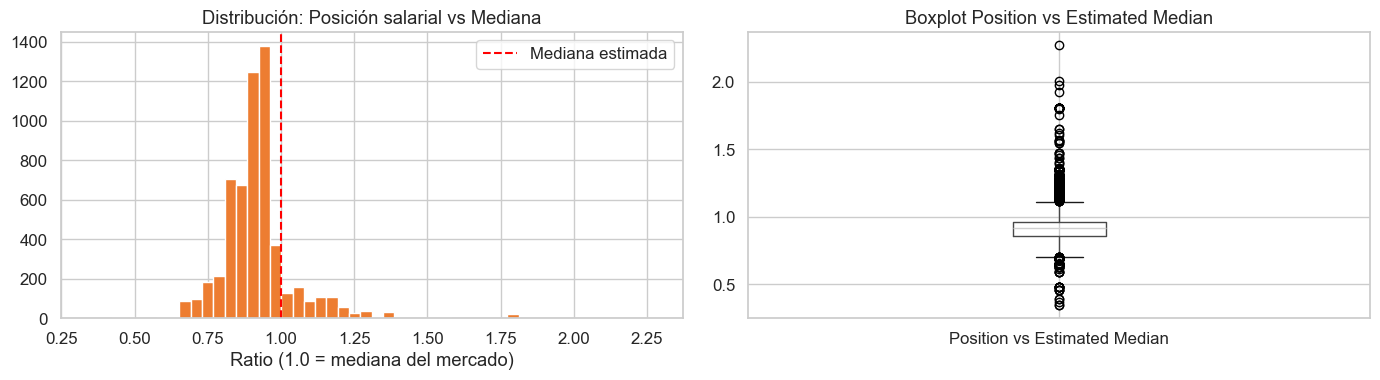


  → 39.1% de nulos — posiblemente cargos sin referencia de mercado disponible.
  → Variable muy relevante: qué tan competitivo es el salario vs el mercado.
  → personas debajo de 1.0 → sugiere que muchos empleados ganan por debajo de la mediana de mercado.
  → es una banda salarial, que va del 80% ¨(piso de la banda), al 120% (techo de la banda).


In [29]:
# ── Variable 37: Position vs Estimated Median ─────────────────────────────
print('VARIABLE 37 — Position vs Estimated Median')
print(df['Position vs Estimated Median'].describe())
print(f'  Nulos: {df["Position vs Estimated Median"].isnull().sum()} ({df["Position vs Estimated Median"].isnull().mean()*100:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df['Position vs Estimated Median'].hist(bins=50, ax=axes[0], color='#ed7d31', edgecolor='white')
axes[0].axvline(1.0, color='red', linestyle='--', label='Mediana estimada')
axes[0].set_title('Distribución: Posición salarial vs Mediana')
axes[0].set_xlabel('Ratio (1.0 = mediana del mercado)')
axes[0].legend()
df.boxplot(column='Position vs Estimated Median', ax=axes[1])
axes[1].set_title('Boxplot Position vs Estimated Median')
plt.tight_layout()
plt.show()

print()
print('  → 39.1% de nulos — posiblemente cargos sin referencia de mercado disponible.')
print('  → Variable muy relevante: qué tan competitivo es el salario vs el mercado.')
print('  → personas debajo de 1.0 → sugiere que muchos empleados ganan por debajo de la mediana de mercado.')
print('  → es una banda salarial, que va del 80% ¨(piso de la banda), al 120% (techo de la banda).')

## 5. Limpieza de las variables 

##filtro que solo queden full time

Con solo 202 Part Time vs 5.590 Full Time la proporción es:

Part Time:  3.5%
Full Time: 96.5%

Con apenas un 3.5% de Part Time, el modelo tendría muy pocos ejemplos para aprender patrones de ese grupo. Lo más recomendable es quedarse solo con Full Time así el modelo será más preciso y los resultados más interpretables para la empresa.
La rotación tiene patrones muy diferentes entre Full Time y Part Time — mezclarlos puede confundir al modelo
Los Part Time suelen tener mayor rotación esperada por naturaleza del contrato, no por factores que el modelo pueda predecir
Las variables como Hours/ Week, Salary, Antigüedad son más comparables entre sí cuando todos son Full Time
El modelo aprende patrones más limpios y consistentes

In [32]:
# Filtrar solo Full Time
df_fulltime = df[df['Contract Type'] == 'Full Time'].copy()

print(f"Registros originales:  {len(df)}")
print(f"Registros eliminados:  {len(df) - len(df_fulltime)}  (Part Time)")
print(f"Registros Full Time:   {len(df_fulltime)}")

# Verificar que no quedó ningún Part Time
print("\nVerificación Contract Type:")
print(df_fulltime['Contract Type'].value_counts())

Registros originales:  5792
Registros eliminados:  202  (Part Time)
Registros Full Time:   5590

Verificación Contract Type:
Contract Type
Full Time    5590
Name: count, dtype: int64


---
## LIMPIEZA VARIABLE Hours/ Week

In [41]:
FFECHA_CORTE = pd.Timestamp('2025-12-31')

df_fulltime['Hire Date'] = pd.to_datetime(df_fulltime['Hire Date'], errors='coerce')
df_fulltime['Hire Year'] = df_fulltime['Hire Date'].dt.year

# Definir rango válido por año
def horas_validas(year):
    if year <= 2022: return (40, 48)
    elif year == 2023: return (40, 47)
    elif year == 2024: return (40, 46)
    else: return (40, 44)

# Recalcular mask_atipicos sobre df_fulltime
mask_atipicos = df_fulltime.apply(
    lambda row: not (horas_validas(row['Hire Year'])[0]
                     <= row['Hours/ Week']
                     <= horas_validas(row['Hire Year'])[1]),
    axis=1
)

# Función de imputación por año
def max_horas_por_año(year):
    if year <= 2022: return 48
    elif year == 2023: return 47
    elif year == 2024: return 46
    else: return 44

# Aplicar corrección solo sobre Full Time
df_fulltime.loc[mask_atipicos, 'Hours/ Week'] = df_fulltime.loc[mask_atipicos, 'Hire Year'].apply(max_horas_por_año)

# Verificar
print(f"Total registros Full Time: {len(df_fulltime)}")
print(f"Atípicos corregidos: {mask_atipicos.sum()}")
print("\nDistribución final corregida:")
print(df_fulltime['Hours/ Week'].value_counts().sort_index())

Total registros Full Time: 5590
Atípicos corregidos: 0

Distribución final corregida:
Hours/ Week
40       1
44    2008
46     341
47     358
48    2882
Name: count, dtype: int64


In [42]:
# Para el valor de 40 horas que es solo 1, se realiza imputación de acuerdo con el máximo legal de su año
mask_40 = df_fulltime['Hours/ Week'] == 40
print(df_fulltime.loc[mask_40, ['Hire Year', 'Hours/ Week']])  # Ver de qué año es

df_fulltime.loc[mask_40, 'Hours/ Week'] = df_fulltime.loc[mask_40, 'Hire Year'].apply(max_horas_por_año)

# Verificar que ya no existe el valor 40
print("\nDistribución final:")
print(df_fulltime['Hours/ Week'].value_counts().sort_index())

      Hire Year  Hours/ Week
4383       2023           40

Distribución final:
Hours/ Week
44    2008
46     341
47     359
48    2882
Name: count, dtype: int64


VARIABLE 3 — Hours/Week (Solo Full Time)
             count
Hours/ Week       
48            2882
44            2008
47             359
46             341

  Media: 46.4 | Mín: 44 | Máx: 48


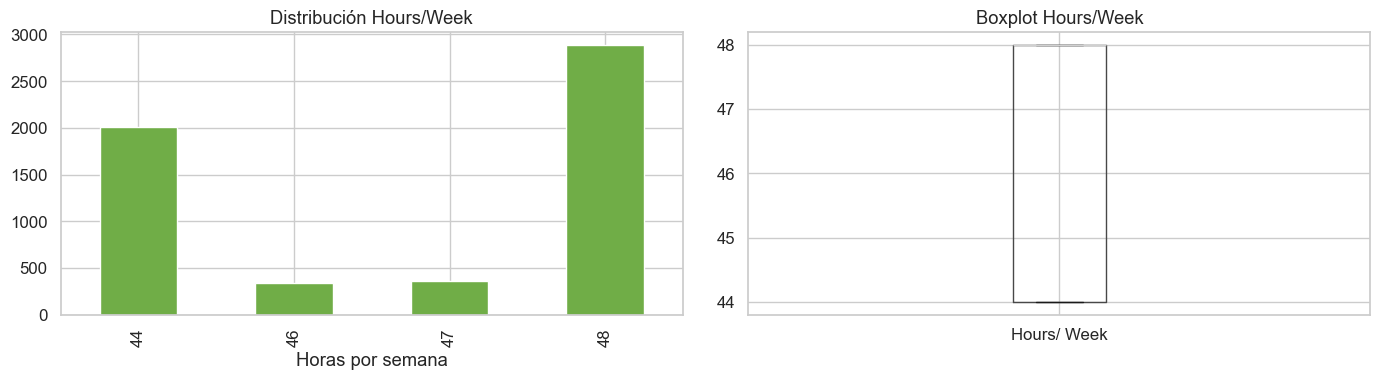

In [43]:
print('VARIABLE 3 — Hours/Week (Solo Full Time)')
print(df_fulltime['Hours/ Week'].value_counts().to_frame('count'))
print()
print(f'  Media: {df_fulltime["Hours/ Week"].mean():.1f} | Mín: {df_fulltime["Hours/ Week"].min()} | Máx: {df_fulltime["Hours/ Week"].max()}')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df_fulltime['Hours/ Week'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='#70ad47')
axes[0].set_title('Distribución Hours/Week')
axes[0].set_xlabel('Horas por semana')
df_fulltime.boxplot(column='Hours/ Week', ax=axes[1])
axes[1].set_title('Boxplot Hours/Week')
plt.tight_layout()
plt.show()

## LIMPIEZA VARIABLE Marital Status
Para el modelo de rotación se recomienda que la variable sea binaria dado que La literatura en recursos humanos y estudios de rotación laboral consistentemente encuentra que:

Personas con pareja estable (casados o unión libre) tienden a tener menor rotación porque tienen mayor responsabilidad financiera del hogar, mayor aversión al riesgo de quedar desempleados y mayor estabilidad en rutinas y arraigo geográfico
Personas sin pareja (solteros, divorciados) tienden a tener mayor rotación porque tienen mayor movilidad y flexibilidad, menos compromisos financieros fijos y mayor disposición a tomar riesgos laborales
Tiene alta interpretabilidad, menor riesgo de Overfitting
Se recomienda no eliminar Marital Status original y conservar ambas variables para que el modelo decida cuál aporta más mediante la importancia de variables

In [47]:
df_fulltime['Tiene_Pareja'] = df_fulltime['Marital Status'].isin(['Married', 'Free Union']).astype(int)

# Verificar
print(df_fulltime['Tiene_Pareja'].value_counts())
print(f"\n  Con pareja (1): {df_fulltime['Tiene_Pareja'].sum()}")
print(f"  Sin pareja (0): {(df_fulltime['Tiene_Pareja'] == 0).sum()}")

Tiene_Pareja
0    3727
1    1863
Name: count, dtype: int64

  Con pareja (1): 1863
  Sin pareja (0): 3727


VARIABLE nueva Tiene_Pareja
Tiene_Pareja
0    3727
1    1863
Name: count, dtype: int64


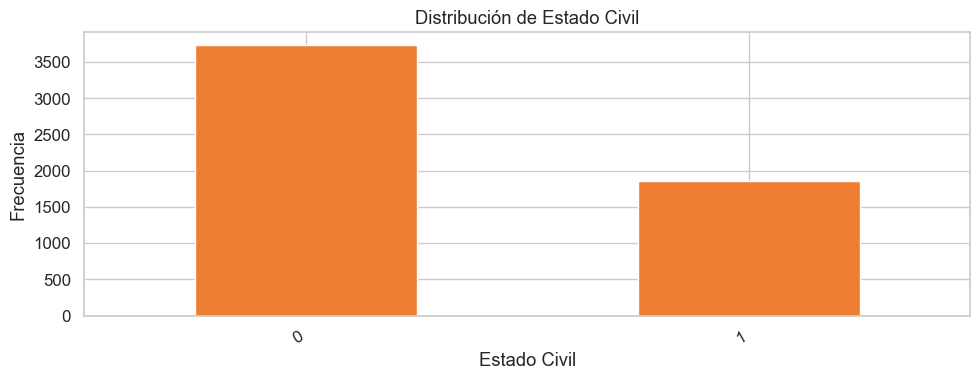

In [48]:
# ── Variable 14: Marital Status ───────────────────────────────────────────
print('VARIABLE nueva Tiene_Pareja')
print(df_fulltime['Tiene_Pareja'].value_counts(dropna=False))

fig, ax = plt.subplots(figsize=(10, 4))
df_fulltime['Tiene_Pareja'].value_counts().plot(kind='bar', ax=ax, color='#ed7d31')
ax.set_title('Distribución de Estado Civil')
ax.set_xlabel('Estado Civil')
ax.set_ylabel('Frecuencia')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

print()

## LIMPIEZA VARIABLE Antigüedad

In [49]:
# Fecha de corte para empleados activos
FECHA_CORTE = pd.Timestamp('2025-12-31')

# Asegurar formato fecha
df_fulltime['Hire Date'] = pd.to_datetime(df_fulltime['Hire Date'], errors='coerce')
df_fulltime['Termination Date'] = pd.to_datetime(df_fulltime['Termination Date'], errors='coerce')

# Fecha final: Termination Date si existe, si no → fecha de corte
df_fulltime['Fecha_Fin'] = df_fulltime['Termination Date'].fillna(FECHA_CORTE)

# Calcular antigüedad solo en meses y años
df_fulltime['Antiguedad_Meses'] = ((df_fulltime['Fecha_Fin'] - df_fulltime['Hire Date']).dt.days / 30.44).round(1)
df_fulltime['Antiguedad_Anos']  = ((df_fulltime['Fecha_Fin'] - df_fulltime['Hire Date']).dt.days / 365.25).round(2)

# Verificar resultado
print(df_fulltime[['Hire Date', 'Termination Date', 'Fecha_Fin',
                   'Antiguedad_Meses', 'Antiguedad_Anos']].head(10))

print("\nEstadísticas de antigüedad (en años):")
print(df_fulltime['Antiguedad_Anos'].describe())

   Hire Date Termination Date  Fecha_Fin  Antiguedad_Meses  Antiguedad_Anos
0 2011-06-20       2013-09-27 2013-09-27           27.3000           2.2700
1 2011-07-15              NaT 2025-12-31          173.6000          14.4600
2 2011-07-11       2014-08-27 2014-08-27           37.5000           3.1300
3 2012-05-28       2013-04-15 2013-04-15           10.6000           0.8800
4 2012-05-30       2015-07-09 2015-07-09           37.3000           3.1100
5 2012-06-11       2014-10-15 2014-10-15           28.1000           2.3400
6 2012-06-11       2014-02-18 2014-02-18           20.3000           1.6900
7 2012-06-11       2013-06-01 2013-06-01           11.7000           0.9700
8 2012-06-11       2013-07-22 2013-07-22           13.3000           1.1100
9 2012-06-11              NaT 2025-12-31          162.6000          13.5600

Estadísticas de antigüedad (en años):
count   5590.0000
mean       2.8214
std        3.2348
min        0.0000
25%        0.5900
50%        1.6300
75%        3.7500

Para modelos de rotación, Antiguedad_Anos es la más usada porque la probabilidad de rotar suele tener un patrón claro por año: alta en el primer año, baja en años intermedios, y variable después de los 5 años.
Los resultados de las estadisticas en años evidencian que la mayoría de la rotación ocurre en los primeros 2 años, lo cual es un patrón muy común en recursos humanos y le dará mucho poder predictivo a esta variable.

In [52]:
# Ver cuántos y qué características tienen
mask_cero = df_fulltime['Antiguedad_Anos'] == 0
print(f"Registros con antigüedad 0: {mask_cero.sum()}")
print(df_fulltime.loc[mask_cero, ['Hire Date', 'Termination Date', 
                                   'Fecha_Fin', 'Antiguedad_Meses',
                                   'Antiguedad_Anos']].head(10))

Registros con antigüedad 0: 35
      Hire Date Termination Date  Fecha_Fin  Antiguedad_Meses  Antiguedad_Anos
265  2014-04-04       2014-04-04 2014-04-04            0.0000           0.0000
273  2014-01-17       2014-01-17 2014-01-17            0.0000           0.0000
1512 2016-06-20       2016-06-20 2016-06-20            0.0000           0.0000
1554 2016-06-07       2016-06-08 2016-06-08            0.0000           0.0000
1561 2016-07-16       2016-07-16 2016-07-16            0.0000           0.0000
1725 2016-09-27       2016-09-28 2016-09-28            0.0000           0.0000
1900 2017-03-03       2017-03-03 2017-03-03            0.0000           0.0000
2144 2017-11-14       2017-11-15 2017-11-15            0.0000           0.0000
2217 2018-02-01       2018-02-02 2018-02-02            0.0000           0.0000
2274 2018-03-02       2018-03-02 2018-03-02            0.0000           0.0000


Como hay 35 registros con antiguedad de cero, se evidencia que todos los casos tienen Hire Date = Termination Date o con 1 día de diferencia, lo que con el redondeo a 2 decimales queda en 0.00. Para un modelo de rotación estos registros no aportan información útil, un empleado que duró 0 o 1 día no tiene comportamiento laboral que el modelo pueda aprender. Lo más recomendable es eliminarlos porque son errores de registro con fecha igual de entrada y salida, probablemente un error en el sistema de RRHH.

¿Por qué eliminarlos y no imputarlos?
Imputar ¿Con qué valor? No hay forma de saber cuánto debieron durar
Dejar losIntroducen ruido — el modelo aprende que "durar 0 días" tiene algún patrón
Eliminar Son solo 35 de 5.590 registros (0.6%) — el impacto es mínimo y el modelo queda más limpio

In [53]:
# Ver detalle completo antes de eliminar
print(f"Registros antes de eliminar: {len(df_fulltime)}")
print(f"Registros con antigüedad 0: {mask_cero.sum()}")

# Eliminar registros con antigüedad 0
df_fulltime = df_fulltime[df_fulltime['Antiguedad_Anos'] > 0].copy()

print(f"Registros después de eliminar: {len(df_fulltime)}")

# Verificar que ya no existen
print(f"\nVerificación — Registros con antigüedad 0: {(df_fulltime['Antiguedad_Anos'] == 0).sum()}")
print("\nNuevo mínimo de antigüedad:")
print(df_fulltime['Antiguedad_Anos'].describe())

Registros antes de eliminar: 5590
Registros con antigüedad 0: 35
Registros después de eliminar: 5555

Verificación — Registros con antigüedad 0: 0

Nuevo mínimo de antigüedad:
count   5555.0000
mean       2.8392
std        3.2371
min        0.0100
25%        0.6100
50%        1.6500
75%        3.7800
max       25.7100
Name: Antiguedad_Anos, dtype: float64


## LIMPIEZA VARIABLE Periodo de prueba

In [54]:
FECHA_CORTE = pd.Timestamp('2025-12-31')
DIAS_PRUEBA = 61  # 2 meses ≈ 61 días

df_fulltime['Hire Date'] = pd.to_datetime(df_fulltime['Hire Date'], errors='coerce')
df_fulltime['Termination Date'] = pd.to_datetime(df_fulltime['Termination Date'], errors='coerce')

# Fecha fin: salida real o fecha de corte si está activo
df_fulltime['Fecha_Fin'] = df_fulltime['Termination Date'].fillna(FECHA_CORTE)

# Calcular días en la empresa
df_fulltime['Dias_Empresa'] = (df_fulltime['Fecha_Fin'] - df_fulltime['Hire Date']).dt.days

# Calcular si pasó el periodo de prueba
df_fulltime['PasoPeriodoPrueba_Calc'] = (df_fulltime['Dias_Empresa'] >= DIAS_PRUEBA).map({True: 'Yes', False: 'No'})

# Comparar con variable original
print("Variable original vs calculada:")
print(pd.crosstab(df_fulltime['Probation Period Completed'], 
                  df_fulltime['PasoPeriodoPrueba_Calc'], 
                  margins=True))

print("\nDistribución variable calculada:")
print(df_fulltime['PasoPeriodoPrueba_Calc'].value_counts())

Variable original vs calculada:
PasoPeriodoPrueba_Calc       No   Yes   All
Probation Period Completed                 
No                           47     0    47
Yes                         577  4931  5508
All                         624  4931  5555

Distribución variable calculada:
PasoPeriodoPrueba_Calc
Yes    4931
No      624
Name: count, dtype: int64


El 11.2% no pasó el periodo de prueba — es una señal muy fuerte de rotación temprana
Usar la variable original hubiera introducido ruido en el modelo con esos 577 mal clasificados
La variable calculada PasoPeriodoPrueba_Calc en lugar de la variable original para el modelo es más confiable al estar basada directamente en las fechas reales de entrada y salida.
Fila 1 — Los 47 marcados por la empresa como "no pasó" el cálculo confirma los 47 como No Coincidencia perfecta, sin discrepancias
Fila 2 — 4.931 confirmados como Yes por el cálculo 577 marcados como Yes por la empresa pero estuvieron menos de 61 días 
La variable original tiene un 10.4% de error — 577 empleados marcados como que sí pasaron la prueba cuando en realidad no completaron los 2 meses

In [38]:
# ── Variables 38-40: AGE, CPI ──────────────────────────────

Para la edad, podemos hacer agrupaciones: centenials, milenials, boomers, etc.

---
## Cambios Natha

In [55]:
###cambiar target equity a binario 
df_fulltime["Target_Equity_Binary"] = (df_fulltime["Target Equity %"] > 0).astype(int)

In [56]:
###cambiar target equity a binario 
df_fulltime["Target_Bonus_Binary"] = (df_fulltime["Target Bonus %"] > 0).astype(int)

In [57]:
## Edad 
def segmentar_edad(x):
    if x < 25:
        return "Early Career"
    elif x < 35:
        return "Junior"
    elif x < 45:
        return "Mid-Level"
    elif x < 55:
        return "Senior"
    else:
        return "Pre-Retirement"

df_fulltime["Age_Group"] = df_fulltime["AGE"].apply(segmentar_edad)

In [58]:
df_fulltime

,Employee Code,Termination Code,Hours/ Week,Currency Code,English Reading Lvl,English Spoken Lvl,English Writing Lvl,Spanish Reading Lvl,Spanish Spoken Lvl,Spanish Writing Lvl,Union,Employee Job ID,Gender,Marital Status,Area,Grouped Department Name,Job Level,Location Description,Type Location,Contract Type,...,Active Supervisor,Supervisor Code,Gropued Supervisor Department,Supervisor Job ID,Probation Period Completed,Position vs Estimated Median,AGE,CPI,Cantidad Salarios Minimos,Termination Date Clean,Hire Year,Tiene_Pareja,Fecha_Fin,Antiguedad_Meses,Antiguedad_Anos,Dias_Empresa,PasoPeriodoPrueba_Calc,Target_Equity_Binary,Target_Bonus_Binary,Age_Group
0,EMP_00001,J,48,COP,3,3,3,4,4,4,N,Cargo 1,Male,Common Law,CLUB OPERATIONS,Merchandising & Inventory,7,Pacífico I,Club,Full Time,...,N,Inactive,Inactive,Cargo 342,Yes,0.9124,33.0000,0.0194,66,2013-09-27,2011,0,2013-09-27,27.3000,2.2700,830,Yes,0,0,Junior
1,EMP_00002,NaN,44,COP,0,0,0,4,4,4,N,Cargo 2,Male,Married,CLUB OPERATIONS,Fresh & Food Operations,5,Caribe I,Club,Full Time,...,Y,EMP_01989,Fresh & Food Operations,Cargo 37,Yes,0.8280,38.0000,0.0510,24,NaT,2011,1,2025-12-31,173.6000,14.4600,5283,Yes,0,0,Mid-Level
2,EMP_00003,J,48,COP,0,0,0,4,4,4,N,Cargo 3,Male,Common Law,CLUB OPERATIONS,Member-Facing Operations,7,Pacífico I,Club,Full Time,...,N,Inactive,Inactive,Cargo 342,Yes,0.9124,29.0000,0.0366,65,2014-08-27,2011,0,2014-08-27,37.5000,3.1300,1143,Yes,0,0,Junior
3,EMP_00004,I,48,COP,2,2,2,4,4,4,N,Cargo 4,Male,Single,CLUB OPERATIONS,Member-Facing Operations,5,Pacífico I,Club,Full Time,...,N,Inactive,Inactive,Cargo 342,Yes,0.8280,27.0000,0.0194,30,2013-04-15,2012,0,2013-04-15,10.6000,0.8800,322,Yes,0,0,Junior
4,EMP_00005,E,48,COP,0,0,0,4,4,4,N,Cargo 5,Female,Married,CLUB OPERATIONS,Finance & Administrative Support,5,Pacífico I,Club,Full Time,...,N,Inactive,Inactive,Cargo 342,Yes,1.0277,33.0000,0.0677,37,2015-07-09,2012,1,2015-07-09,37.3000,3.1100,1135,Yes,0,0,Junior
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5787,EMP_05788,NaN,44,COP,0,0,0,4,4,4,N,Cargo 46,Female,Free Union,CLUB OPERATIONS,Commercial Operations,4,Pacífico I,Club,Full Time,...,N,Inactive,Inactive,Cargo 342,No,1.1294,32.0000,0.0510,25,NaT,2025,1,2025-12-31,0.5000,0.0400,15,No,0,0,Junior
5788,EMP_05789,NaN,44,COP,0,0,0,0,0,0,N,Cargo 74,Unknown,Married,CLUB OPERATIONS,Member-Facing Operations,6,Centro Occidente I,Club,Full Time,...,Y,EMP_01768,Member-Facing Operations,Cargo 3,No,1.0550,42.0000,0.0510,44,NaT,2025,1,2025-12-31,0.5000,0.0400,14,No,0,0,Mid-Level
5789,EMP_05790,NaN,44,COP,0,0,0,0,0,0,N,Cargo 17,Male,Single,CLUB OPERATIONS,Merchandising & Inventory,1,Centro Norte II,Club,Full Time,...,Y,EMP_02178,Merchandising & Inventory,Cargo 16,No,0.9166,29.0000,0.0510,14,NaT,2025,0,2025-12-31,0.4000,0.0400,13,No,0,0,Junior
5790,EMP_05791,NaN,44,COP,0,0,0,0,0,0,N,Cargo 31,Female,Single,CLUB OPERATIONS,Member-Facing Operations,2,Centro Norte II,Club,Full Time,...,Y,EMP_01553,Member-Facing Operations,Cargo 3,No,0.9596,31.0000,0.0510,16,NaT,2025,0,2025-12-31,0.4000,0.0400,13,No,0,0,Junior


In [59]:
df_fulltime["Target_Bonus_Binary"].value_counts()

Target_Bonus_Binary
0    5410
1     145
Name: count, dtype: int64

In [60]:
df_fulltime["Target_Equity_Binary"].value_counts()

Target_Equity_Binary
0    5479
1      76
Name: count, dtype: int64

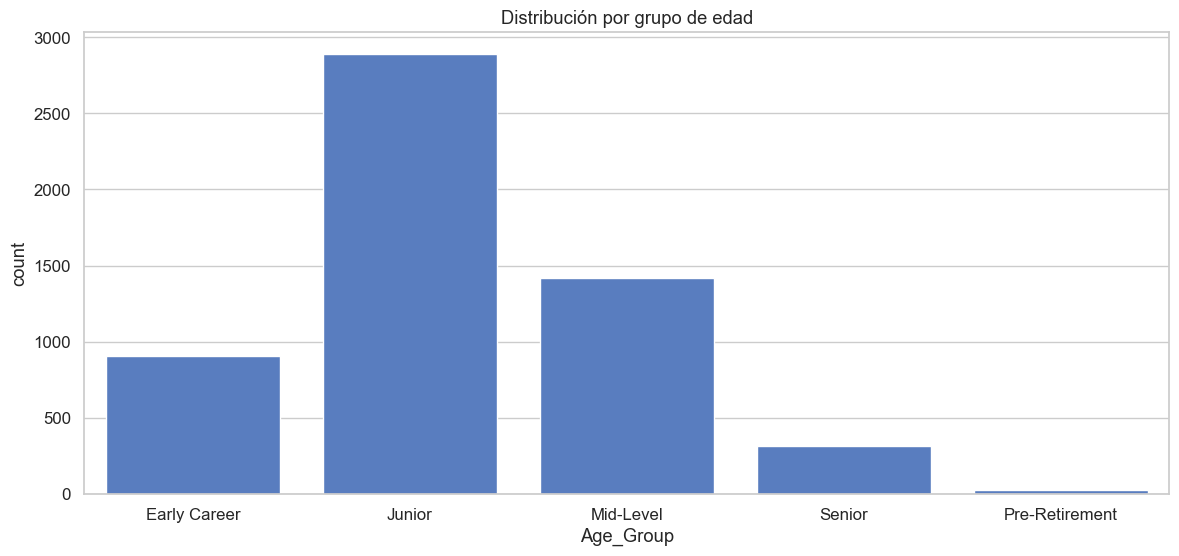

In [61]:
## Distribución por grupo de edad
order = ["Early Career", "Junior", "Mid-Level", "Senior", "Pre-Retirement"]

sns.countplot(x=df_fulltime["Age_Group"], order=order)
plt.title("Distribución por grupo de edad")
plt.show()

In [63]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# ==========================================
# 2. COLUMNAS DE INGLÉS
# ==========================================
cols = ["English Reading Lvl", "English Spoken Lvl", "English Writing Lvl"]

# Asegurar que sean numéricas
for col in cols:
    df_fulltime[col] = pd.to_numeric(df_fulltime[col], errors="coerce")

# Eliminar nulos en esas columnas
df_pca = df_fulltime.dropna(subset=cols).copy()

# ==========================================
# 3. PCA
# ==========================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_pca[cols])

pca = PCA(n_components=1)
df_pca["English_Level_Index"] = pca.fit_transform(X_scaled)

# Pesos del PCA
pesos = pd.Series(pca.components_[0], index=cols)
print("Pesos PCA:")
print(pesos)

print("\nVarianza explicada:")
print(pca.explained_variance_ratio_[0])

# ==========================================
# 4. REESCALAR A 0–4
# ==========================================
min_val = df_pca["English_Level_Index"].min()
max_val = df_pca["English_Level_Index"].max()

df_pca["English_Level_Index_0_4"] = (
    (df_pca["English_Level_Index"] - min_val) / (max_val - min_val)
) * 4

# ==========================================
# 5. VOLVER A LA BASE FULL TIME ← CORRECCIÓN
# ==========================================
df_fulltime.loc[df_pca.index, "English_Level_Index"] = df_pca["English_Level_Index"]
df_fulltime.loc[df_pca.index, "English_Level_Index_0_4"] = df_pca["English_Level_Index_0_4"]

# Columna final limpia
df_fulltime["English_Level"] = df_fulltime["English_Level_Index_0_4"]

# ==========================================
# 6. VER RESULTADOS
# ==========================================
print(df_fulltime[cols + ["English_Level_Index", "English_Level_Index_0_4", "English_Level"]].head())

Pesos PCA:
English Reading Lvl   0.5774
English Spoken Lvl    0.5780
English Writing Lvl   0.5767
dtype: float64

Varianza explicada:
0.9899473678905335
   English Reading Lvl  English Spoken Lvl  English Writing Lvl  \
0                    3                   3                    3   
1                    0                   0                    0   
2                    0                   0                    0   
3                    2                   2                    2   
4                    0                   0                    0   

   English_Level_Index  English_Level_Index_0_4  English_Level  
0               3.2676                   3.0000         3.0000  
1              -0.8859                   0.0000         0.0000  
2              -0.8859                   0.0000         0.0000  
3               1.8831                   2.0000         2.0000  
4              -0.8859                   0.0000         0.0000  


In [64]:
df_fulltime

,Employee Code,Termination Code,Hours/ Week,Currency Code,English Reading Lvl,English Spoken Lvl,English Writing Lvl,Spanish Reading Lvl,Spanish Spoken Lvl,Spanish Writing Lvl,Union,Employee Job ID,Gender,Marital Status,Area,Grouped Department Name,Job Level,Location Description,Type Location,Contract Type,...,Supervisor Job ID,Probation Period Completed,Position vs Estimated Median,AGE,CPI,Cantidad Salarios Minimos,Termination Date Clean,Hire Year,Tiene_Pareja,Fecha_Fin,Antiguedad_Meses,Antiguedad_Anos,Dias_Empresa,PasoPeriodoPrueba_Calc,Target_Equity_Binary,Target_Bonus_Binary,Age_Group,English_Level_Index,English_Level_Index_0_4,English_Level
0,EMP_00001,J,48,COP,3,3,3,4,4,4,N,Cargo 1,Male,Common Law,CLUB OPERATIONS,Merchandising & Inventory,7,Pacífico I,Club,Full Time,...,Cargo 342,Yes,0.9124,33.0000,0.0194,66,2013-09-27,2011,0,2013-09-27,27.3000,2.2700,830,Yes,0,0,Junior,3.2676,3.0000,3.0000
1,EMP_00002,NaN,44,COP,0,0,0,4,4,4,N,Cargo 2,Male,Married,CLUB OPERATIONS,Fresh & Food Operations,5,Caribe I,Club,Full Time,...,Cargo 37,Yes,0.8280,38.0000,0.0510,24,NaT,2011,1,2025-12-31,173.6000,14.4600,5283,Yes,0,0,Mid-Level,-0.8859,0.0000,0.0000
2,EMP_00003,J,48,COP,0,0,0,4,4,4,N,Cargo 3,Male,Common Law,CLUB OPERATIONS,Member-Facing Operations,7,Pacífico I,Club,Full Time,...,Cargo 342,Yes,0.9124,29.0000,0.0366,65,2014-08-27,2011,0,2014-08-27,37.5000,3.1300,1143,Yes,0,0,Junior,-0.8859,0.0000,0.0000
3,EMP_00004,I,48,COP,2,2,2,4,4,4,N,Cargo 4,Male,Single,CLUB OPERATIONS,Member-Facing Operations,5,Pacífico I,Club,Full Time,...,Cargo 342,Yes,0.8280,27.0000,0.0194,30,2013-04-15,2012,0,2013-04-15,10.6000,0.8800,322,Yes,0,0,Junior,1.8831,2.0000,2.0000
4,EMP_00005,E,48,COP,0,0,0,4,4,4,N,Cargo 5,Female,Married,CLUB OPERATIONS,Finance & Administrative Support,5,Pacífico I,Club,Full Time,...,Cargo 342,Yes,1.0277,33.0000,0.0677,37,2015-07-09,2012,1,2015-07-09,37.3000,3.1100,1135,Yes,0,0,Junior,-0.8859,0.0000,0.0000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5787,EMP_05788,NaN,44,COP,0,0,0,4,4,4,N,Cargo 46,Female,Free Union,CLUB OPERATIONS,Commercial Operations,4,Pacífico I,Club,Full Time,...,Cargo 342,No,1.1294,32.0000,0.0510,25,NaT,2025,1,2025-12-31,0.5000,0.0400,15,No,0,0,Junior,-0.8859,0.0000,0.0000
5788,EMP_05789,NaN,44,COP,0,0,0,0,0,0,N,Cargo 74,Unknown,Married,CLUB OPERATIONS,Member-Facing Operations,6,Centro Occidente I,Club,Full Time,...,Cargo 3,No,1.0550,42.0000,0.0510,44,NaT,2025,1,2025-12-31,0.5000,0.0400,14,No,0,0,Mid-Level,-0.8859,0.0000,0.0000
5789,EMP_05790,NaN,44,COP,0,0,0,0,0,0,N,Cargo 17,Male,Single,CLUB OPERATIONS,Merchandising & Inventory,1,Centro Norte II,Club,Full Time,...,Cargo 16,No,0.9166,29.0000,0.0510,14,NaT,2025,0,2025-12-31,0.4000,0.0400,13,No,0,0,Junior,-0.8859,0.0000,0.0000
5790,EMP_05791,NaN,44,COP,0,0,0,0,0,0,N,Cargo 31,Female,Single,CLUB OPERATIONS,Member-Facing Operations,2,Centro Norte II,Club,Full Time,...,Cargo 3,No,0.9596,31.0000,0.0510,16,NaT,2025,0,2025-12-31,0.4000,0.0400,13,No,0,0,Junior,-0.8859,0.0000,0.0000


#Solo dejar las columnas que se necesitan para correr modelos